## Importing libraries + reading data from csv format into pandas.DataFrame

In [21]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from IPython.display import display

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
from pathlib import Path

DATA_PATH = Path("..") / "data" / "raw"

df_air_reserve = pd.read_csv(DATA_PATH / "air_reserve.csv")
df_air_store_info = pd.read_csv(DATA_PATH / "air_store_info.csv")
df_air_visit_data = pd.read_csv(DATA_PATH / "air_visit_data.csv")
df_date_info = pd.read_csv(DATA_PATH / "date_info.csv")
df_hpg_reserve = pd.read_csv(DATA_PATH / "hpg_reserve.csv")
df_hpg_store_info = pd.read_csv(DATA_PATH / "hpg_store_info.csv")
df_store_id_relation = pd.read_csv(DATA_PATH / "store_id_relation.csv")

In [23]:
data_frames = [
        df_air_reserve, df_air_store_info, df_air_visit_data, df_date_info,
        df_hpg_reserve, df_hpg_store_info, df_store_id_relation
    ]

data_frames_names = [
    "air_reserve", "air_store_info", "air_visit_data", "date_info",
    "hpg_reserve", "hpg_store_info", "store_id_relation"
]

## Counting nan values and unique values in the dataframes

In [24]:
from restaurant_visitor_eda.dataset import count_unique_and_nans

In [25]:
for i, df in enumerate(data_frames):
    print(data_frames_names[i])
    #display(count_unique_and_nans(df))
    print(count_unique_and_nans(df))

air_reserve
                  nan percentage  unique
air_store_id                 0.0     314
visit_datetime               0.0    4975
reserve_datetime             0.0    7513
reserve_visitors             0.0      71
air_store_info
                nan percentage  unique
air_store_id               0.0     829
air_genre_name             0.0      14
air_area_name              0.0     103
latitude                   0.0     108
longitude                  0.0     108
air_visit_data
              nan percentage  unique
air_store_id             0.0     829
visit_date               0.0     478
visitors                 0.0     204
date_info
               nan percentage  unique
calendar_date             0.0     517
day_of_week               0.0       7
holiday_flg               0.0       2
hpg_reserve
                  nan percentage  unique
hpg_store_id                 0.0   13325
visit_datetime               0.0    9847
reserve_datetime             0.0   11450
reserve_visitors             0.0 

## Conclusion: 

1) There are __no__ nan values in the data set, however, this does __not__ particularly mean that the data set is complete or consistent. The next points will look into my arguments in favour of this position

2) There $829$ unique restaurants in the air_store_info table, while only $314$ are covered in air_reserve. This means that we do not have any information about reserves made in $(829 - 314) = 515$ restaurants through air service.

3) The store_id_relation has only $150$ rows. Thus, we can join information from two services only for $150$ places, which is significantly smaller than the total number of the restaraunts in the area


## Target Value 

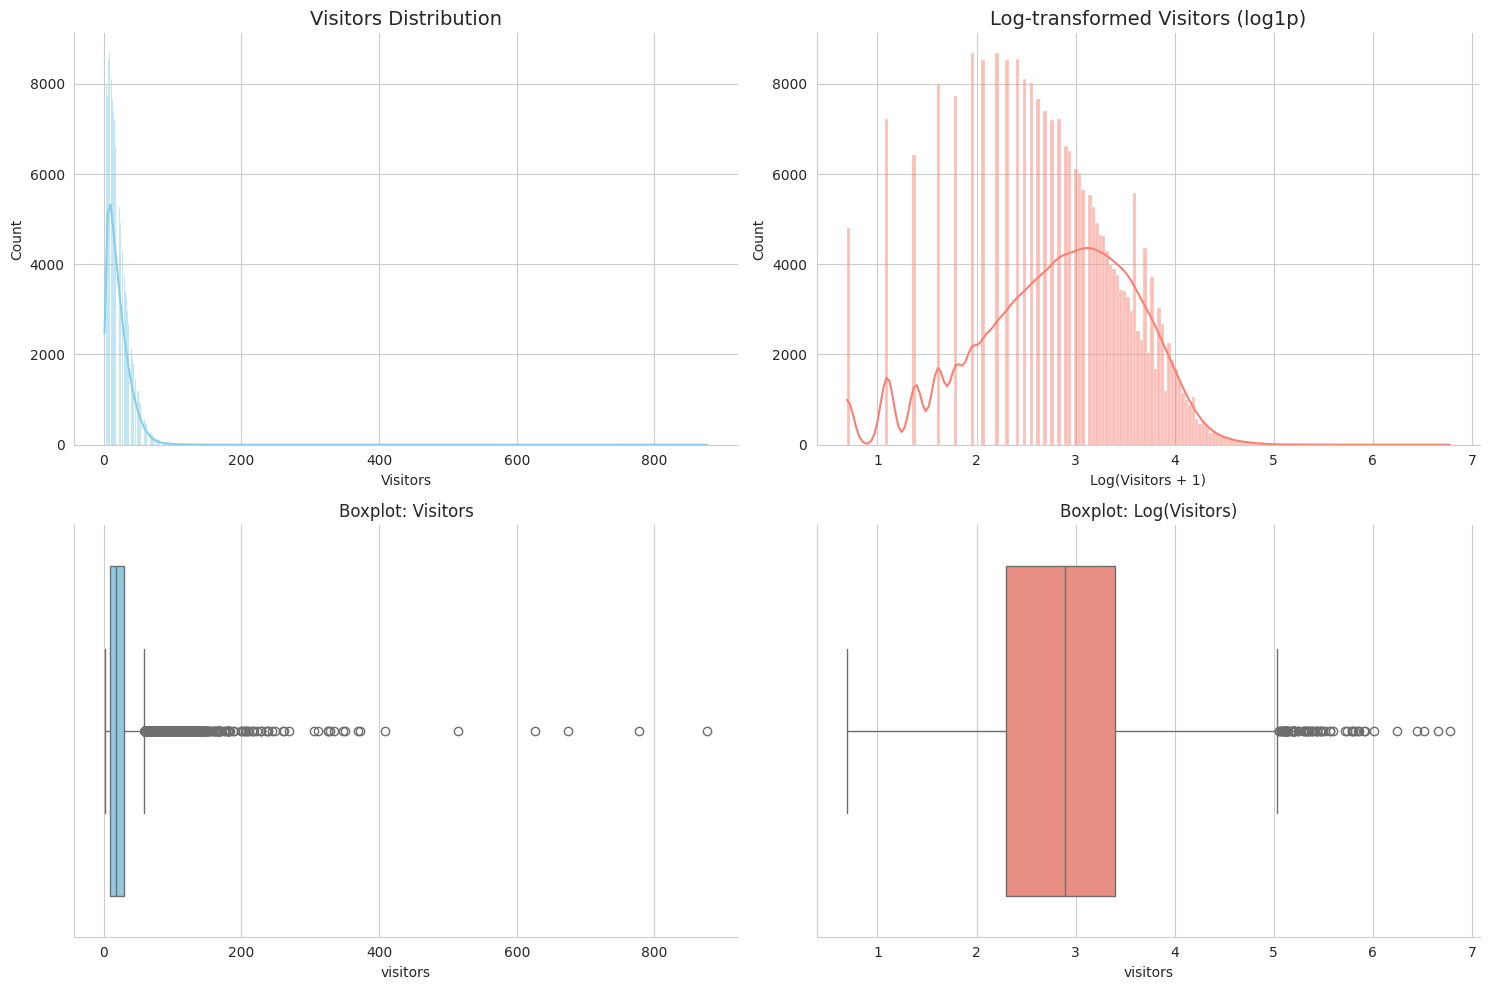

In [26]:
from restaurant_visitor_eda.plots import plot_target_distribution

plot_target_distribution(df_air_visit_data)

In [27]:
from restaurant_visitor_eda.dataset import get_stats

get_stats(pd.DataFrame(df_air_visit_data['visitors']))

,visitors
count,252108.000
mean,20.974
std,16.757
min,1.000
25%,9.000
50%,17.000
75%,29.000
95%,52.000
99%,73.000
max,877.000


In [28]:
get_stats(pd.DataFrame(np.log1p(df_air_visit_data['visitors'])))

,visitors
count,252108.000
mean,2.803
std,0.808
min,0.693
25%,2.303
50%,2.890
75%,3.401
95%,3.970
99%,4.304
max,6.778


## Conclusion!!!


## Features Analysis



### Restaurants' genres


#### Distribution of the geners


/home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/restaurant_visitor_eda/plots.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_air_genre_name, orient='h', palette='viridis')


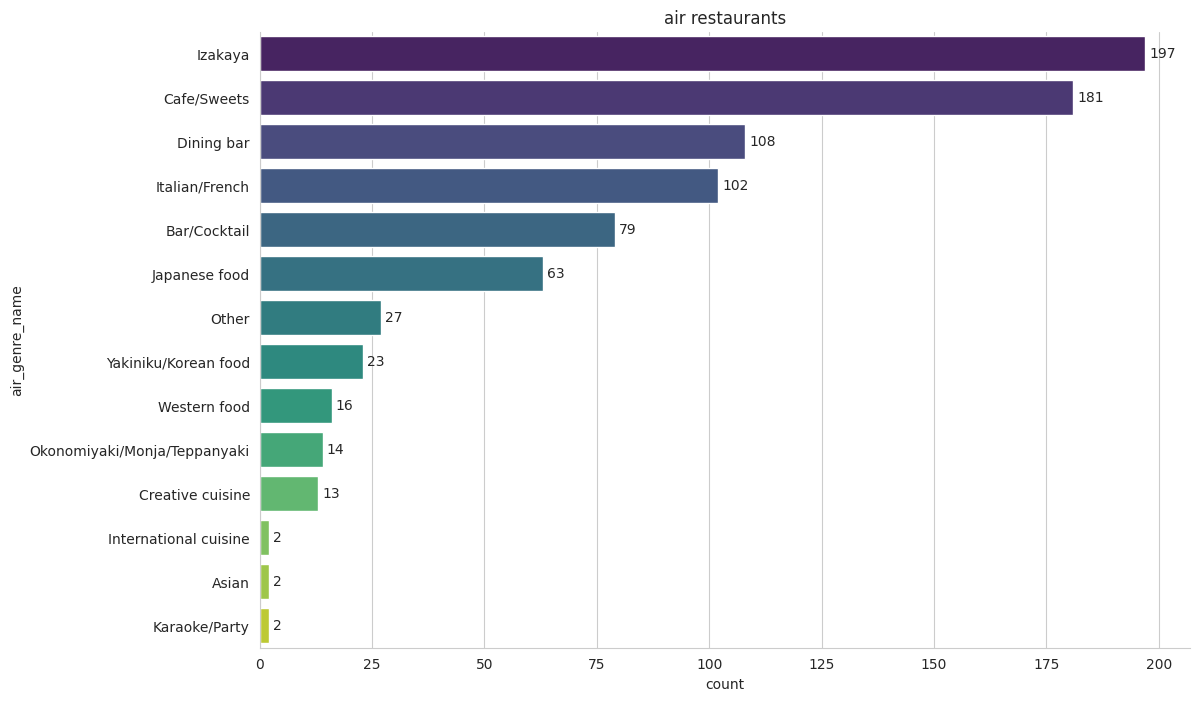

In [29]:
from restaurant_visitor_eda.plots import build_barplot_for_air_genres
build_barplot_for_air_genres(df_air_store_info)

/home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/restaurant_visitor_eda/plots.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_hpg_genre_name, orient='h', palette = 'viridis')


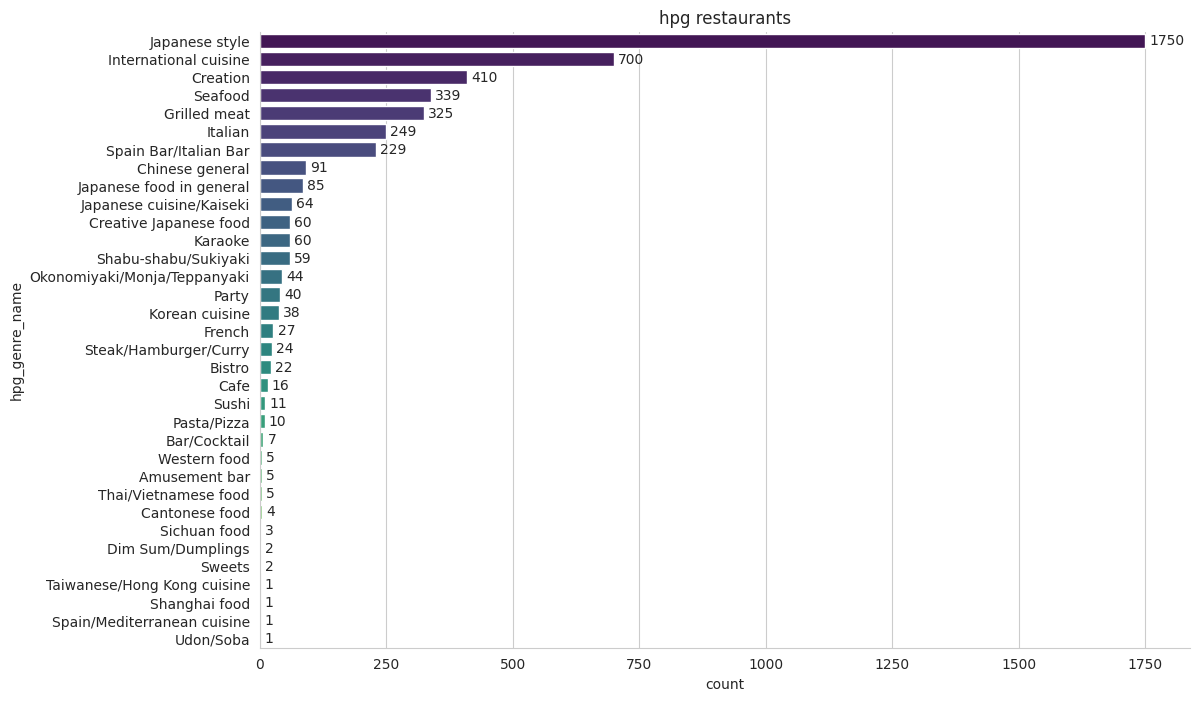

In [30]:
from restaurant_visitor_eda.plots import build_barplot_for_hpg_genres
build_barplot_for_hpg_genres(df_hpg_store_info)

/home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/restaurant_visitor_eda/plots.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


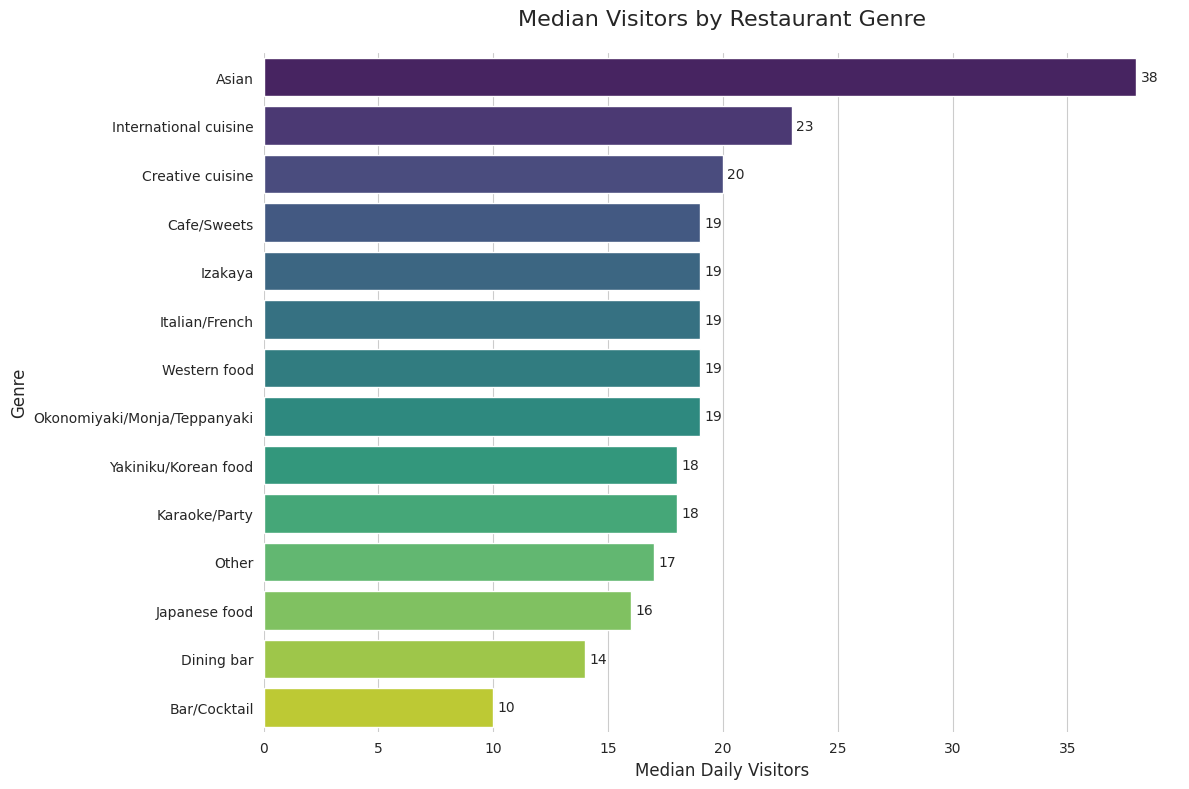

In [31]:
from restaurant_visitor_eda.plots import plot_median_visitors_per_genre, plot_visitors_boxplot_air
plot_median_visitors_per_genre(pd.merge(df_air_visit_data, df_air_store_info, on='air_store_id'))

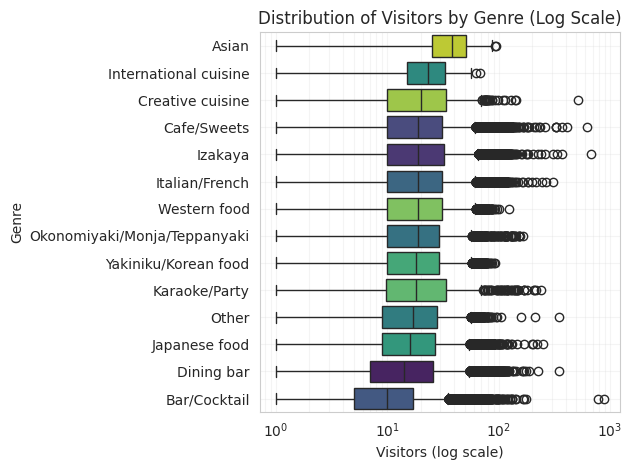

In [32]:
plot_visitors_boxplot_air(pd.merge(df_air_visit_data, df_air_store_info, on='air_store_id'))

In [33]:
df_air_store_info[['prefecture', 'district', 'block']] = df_air_store_info['air_area_name'].str.strip().str.split(' ', n=2, expand=True)


In [34]:
df_air_store_info

,air_store_id,air_genre_name,air_area_name,latitude,longitude,prefecture,district,block
0,air_0f0cdeee6c9bf3d7,Italian/French,Hyōgo-ken Kōbe-shi Kumoidōri,34.695124,135.197853,Hyōgo-ken,Kōbe-shi,Kumoidōri
1,air_7cc17a324ae5c7dc,Italian/French,Hyōgo-ken Kōbe-shi Kumoidōri,34.695124,135.197853,Hyōgo-ken,Kōbe-shi,Kumoidōri
2,air_fee8dcf4d619598e,Italian/French,Hyōgo-ken Kōbe-shi Kumoidōri,34.695124,135.197853,Hyōgo-ken,Kōbe-shi,Kumoidōri
3,air_a17f0778617c76e2,Italian/French,Hyōgo-ken Kōbe-shi Kumoidōri,34.695124,135.197853,Hyōgo-ken,Kōbe-shi,Kumoidōri
4,air_83db5aff8f50478e,Italian/French,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599,Tōkyō-to,Minato-ku,Shibakōen
...,...,...,...,...,...,...,...,...
824,air_9bf595ef095572fb,International cuisine,Tōkyō-to Shibuya-ku Shibuya,35.661777,139.704051,Tōkyō-to,Shibuya-ku,Shibuya
825,air_764f71040a413d4d,Asian,Tōkyō-to Shibuya-ku Shibuya,35.661777,139.704051,Tōkyō-to,Shibuya-ku,Shibuya
826,air_10bbe8acd943d8f6,Asian,Tōkyō-to Shibuya-ku Shibuya,35.661777,139.704051,Tōkyō-to,Shibuya-ku,Shibuya
827,air_7514d90009613cd6,Karaoke/Party,Hokkaidō Sapporo-shi Minami 3 Jōnishi,43.055460,141.340956,Hokkaidō,Sapporo-shi,Minami 3 Jōnishi


/home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/restaurant_visitor_eda/plots.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_air_genre_prefecture, orient='h', palette='viridis')


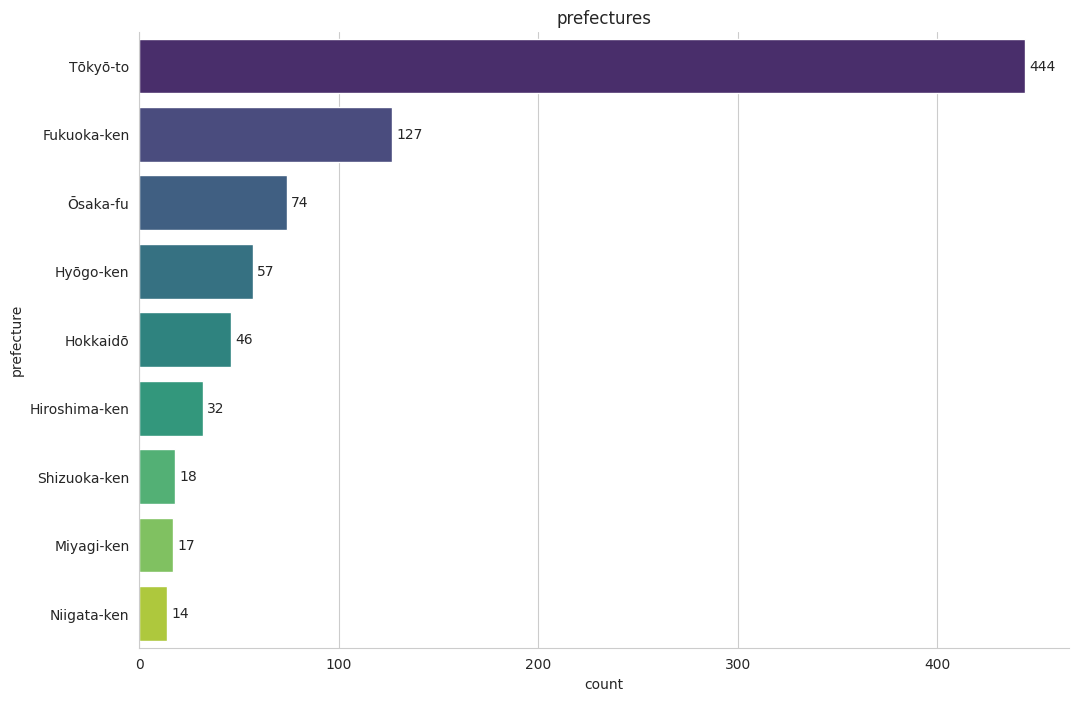

/home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/restaurant_visitor_eda/plots.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_air_genre_district, orient='h', palette='viridis')


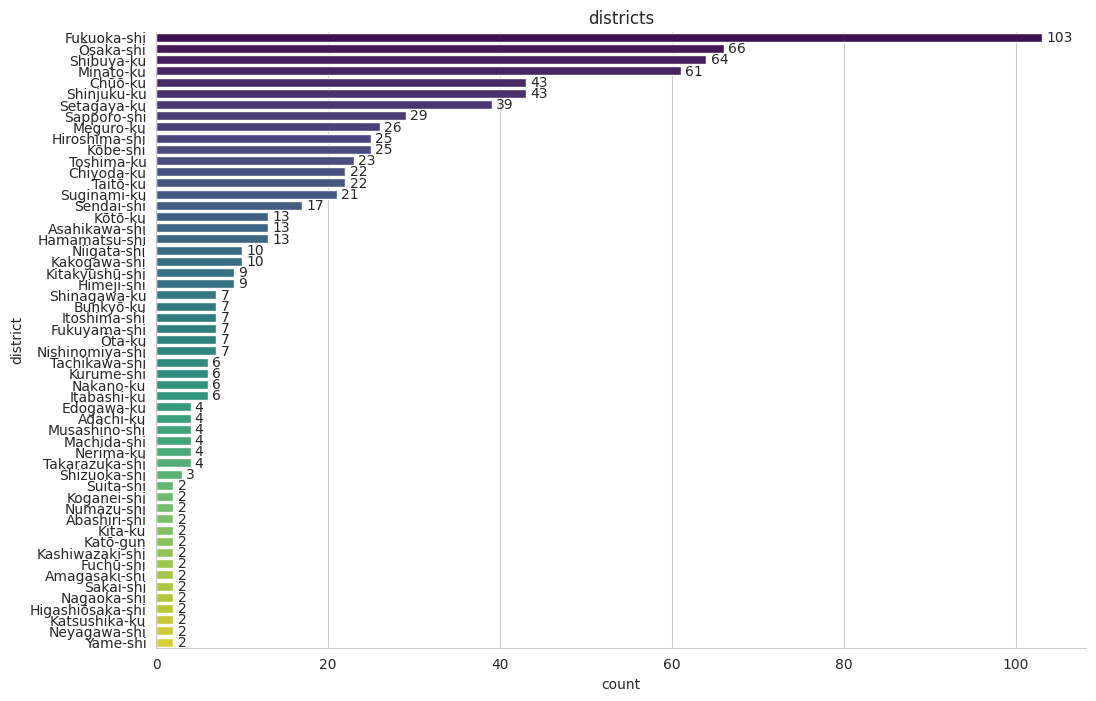

/home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/restaurant_visitor_eda/plots.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_air_genre_block, orient='h', hue=y, legend=False, palette='viridis')


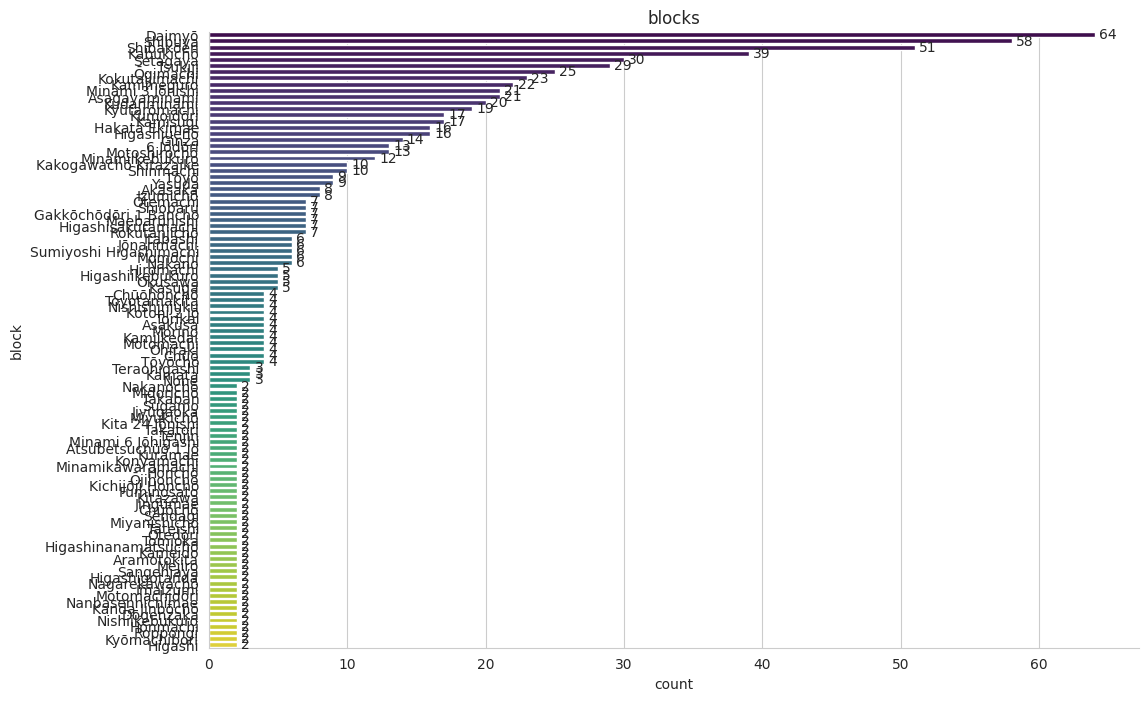

In [35]:
from restaurant_visitor_eda.plots import build_barplot_for_air_prefectures, build_barplot_for_air_districts, build_barplot_for_air_blocks
build_barplot_for_air_prefectures(data=df_air_store_info)
build_barplot_for_air_districts(data=df_air_store_info)
build_barplot_for_air_blocks(data=df_air_store_info)